In [6]:
import pandas as pd

In [9]:
info = {
    "name" : ["vaishu", "anniya", "babu"],
   "CGPA" : [9.5, 6.9, 9.6 ]
}
df = pd.DataFrame(info)
print(df)

     name  CGPA
0  vaishu   9.5
1  anniya   6.9
2    babu   9.6


In [14]:
s = pd.Series([1, 2, 3, 4, 5])
print(s)
print(type(s))
print(s[2])

0    1
1    2
2    3
3    4
4    5
dtype: int64
<class 'pandas.core.series.Series'>
3


In [18]:
c = pd.Series([1, 2, 3, 4, 5], index = ["adam","bro", "sis", "darling", "baby"])
print(c)
print(c["adam"])

adam       1
bro        2
sis        3
darling    4
baby       5
dtype: int64
1


In [34]:
# csv data
df = pd.read_csv("employees.csv")
print(df, type(df))
df.head(1)
df.tail(2)
df.sample(5)
df.describe()
df.info()
df.nunique()

     ID         Name  Age Department  Salary
0  E001   Amit Kumar   25         IT   45000
1  E002  Priya Singh   28         HR   40000
2  E003  Rahul Verma   32    Finance   55000
3  E004  Neha Sharma   26  Marketing   42000
4  E005  Arjun Patel   30         IT   60000 <class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          5 non-null      object
 1   Name        5 non-null      object
 2   Age         5 non-null      int64 
 3   Department  5 non-null      object
 4   Salary      5 non-null      int64 
dtypes: int64(2), object(3)
memory usage: 332.0+ bytes


ID            5
Name          5
Age           5
Department    4
Salary        5
dtype: int64

In [25]:
# json data
df = pd.read_json("employees.json")
print(df, type(df))

     ID         Name  Age Department  Salary
0  E001   Amit Kumar   25         IT   45000
1  E002  Priya Singh   28         HR   40000
2  E003  Rahul Verma   32    Finance   55000
3  E004  Neha Sharma   26  Marketing   42000
4  E005  Arjun Patel   30         IT   60000 <class 'pandas.core.frame.DataFrame'>


In [28]:
import pandas as pd

In [81]:
df = pd.read_csv("raw_data.csv")
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.lower().copy()
print(df)


                                                             data = [
    ["ID" "Name"         "Age" "Country" "Gender" "Income"]       NaN
    [101  "Amit Kumar"   25    "India"   "Male"   45000]          NaN
    [102  "Priya Singh"  28    "India"   "Female" 52000]          NaN
    [103  "Rahul Verma"  32    "India"   "Male"   60000]          NaN
    [104  "Neha Sharma"  26    "India"   "Female" 48000]          NaN
    [105  "John Smith"   35    "USA"     "Male"   75000]          NaN
    [106  "Emma Brown"   29    "USA"     "Female" 68000]          NaN
    [107  "David Wilson" 41    "Canada"  "Male"   82000]          NaN
    [108  "Sophia Davis" 31    "Canada"  "Female" 71000]          NaN
    [109  "Mohammed Ali" 27    "UAE"     "Male"   55000]          NaN
    [110  "Sara Khan"    24    "UAE"     "Female" 47000]          NaN
]         NaN            NaN   NaN       NaN      NaN             NaN


In [60]:
import pandas as pd

# Create DataFrame
data = {
    "ID": [101, 102, 103, 104, 105],
    "Name": ["Amit Kumar", "Priya Singh", "Rahul Verma", "Neha Sharma", "John Smith"],
    "Age": [25, 28, 32, 26, 35],
    "Country": ["India", "India", "India", "India", "USA"],
    "Gender": ["Male", "Female", "Male", "Female", "Male"],
    "Income": [45000, 52000, 60000, 48000, 75000]
}

df = pd.DataFrame(data)

print("Original DataFrame")
print(df)

# -------------------------
# TRANSFORMATIONS
# -------------------------

# 1. Convert column names to lowercase
df.columns = df.columns.str.lower()

# 2. Convert all string columns to lowercase
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.lower()

# 3. Map gender values
gender_map = {
    "male": "M",
    "female": "F",
    "other": None
}

df["gender"] = df["gender"].map(gender_map)

# 4. Create Tax Column
df["tax"] = df["income"].apply(
    lambda x: "20%" if x >= 50000 else "10%"
)

# 5. Create Bonus Column
df["bonus"] = df["income"] * 0.10

# 6. Create Total Income Column
df["total_income"] = df["income"] + df["bonus"]

# 7. Create Age Group Column
df["age_group"] = df["age"].apply(
    lambda x: "Young" if x < 30 else "Adult"
)

# 8. Create Income Category Column
df["income_category"] = pd.cut(
    df["income"],
    bins=[0, 50000, 70000, 100000],
    # labels=["Low", "Medium", "High"]
)

# 9. Sort by Income
# df = df.sort_values(by="income", ascending=False)


# sdhfgfn
# by default in descending ordere
df = df.sort_values( by="income").copy()



#
# -------------------------
# DISPLAY RESULT
# -------------------------

print("\nTransformed DataFrame")
print(df)

# Save to CSV
df.to_csv("transformed_employees.csv", index=False)

print("\nFile saved successfully!")


df.columns = ["ID", "Name", "Age", "Country", "Gender", "Income", "Tax", "Bonus", "Total_Income", "Age_Group", "Income_Category"] 
df.rename(columns={"Income":"Saalry"})
df.rename(index={1:"First"})


Original DataFrame
    ID         Name  Age Country  Gender  Income
0  101   Amit Kumar   25   India    Male   45000
1  102  Priya Singh   28   India  Female   52000
2  103  Rahul Verma   32   India    Male   60000
3  104  Neha Sharma   26   India  Female   48000
4  105   John Smith   35     USA    Male   75000

Transformed DataFrame
    id         name  age country gender  income  tax   bonus  total_income  \
0  101   amit kumar   25   india      M   45000  10%  4500.0       49500.0   
3  104  neha sharma   26   india      F   48000  10%  4800.0       52800.0   
1  102  priya singh   28   india      F   52000  20%  5200.0       57200.0   
2  103  rahul verma   32   india      M   60000  20%  6000.0       66000.0   
4  105   john smith   35     usa      M   75000  20%  7500.0       82500.0   

  age_group  income_category  
0     Young       (0, 50000]  
3     Young       (0, 50000]  
1     Young   (50000, 70000]  
2     Adult   (50000, 70000]  
4     Adult  (70000, 100000]  

File sav

,ID,Name,Age,Country,Gender,Income,Tax,Bonus,Total_Income,Age_Group,Income_Category
0,101,amit kumar,25,india,M,45000,10%,4500.0,49500.0,Young,"(0, 50000]"
3,104,neha sharma,26,india,F,48000,10%,4800.0,52800.0,Young,"(0, 50000]"
First,102,priya singh,28,india,F,52000,20%,5200.0,57200.0,Young,"(50000, 70000]"
2,103,rahul verma,32,india,M,60000,20%,6000.0,66000.0,Adult,"(50000, 70000]"
4,105,john smith,35,usa,M,75000,20%,7500.0,82500.0,Adult,"(70000, 100000]"


In [71]:
# grouing
df.groupby("Country")["Income"].mean()
df.groupby("Country")["Income"].min()
df.groupby("Country")["Income"].max()

df.groupby("Gender")["Income"].mean()
df.groupby("Gender")["Income"].max()

# multiple
df.groupby("Country")["Income"].agg(["mean", "min","max"])
 # aggregate function
df.groupby("Country")["Income"].aggregate(avg_salary="mean",min_saalry="min",max_salary="max")


,avg_salary,min_saalry,max_salary
Country,,,
india,51250.0,45000,60000
usa,75000.0,75000,75000


In [109]:
import pandas as pd

df = pd.DataFrame({
    "country": ["india", "usa", "canada"],
    "year": [2024, 2024, 2024],
    "sales": [50000, 80000, 65000],
    "salary": [30000, 45000, 38000],
    "profit": [12000, 20000, 15000],
    "tax": [10, 20, 30]
})
# df.columns = df.columns.str.lower()
# df[df.select_dtypes(include="object").columns] = (
#     df.select_dtypes(include="object").apply(lambda x: x.str.lower())
# 
melted_df = df.melt(
    id_vars=["country", "year"],
    value_vars=["sales", "profit", "tax"],
    var_name="metrics",
    value_name="value"
)
melted_df.pivot(
    index=["country","year"],
    columns="metrics",
    values="value"
)

,metrics,profit,sales,tax
country,year,,,
canada,2024,15000,65000,30
india,2024,12000,50000,10
usa,2024,20000,80000,20


In [110]:
df

,country,year,sales,salary,profit,tax
0,india,2024,50000,30000,12000,10
1,usa,2024,80000,45000,20000,20
2,canada,2024,65000,38000,15000,30


In [108]:
melted_df

,country,year,metrics,value
0,india,2024,sales,50000
1,usa,2024,sales,80000
2,canada,2024,sales,65000
3,india,2024,profit,12000
4,usa,2024,profit,20000
5,canada,2024,profit,15000
6,india,2024,tax,10
7,usa,2024,tax,20
8,canada,2024,tax,30


<Axes: >

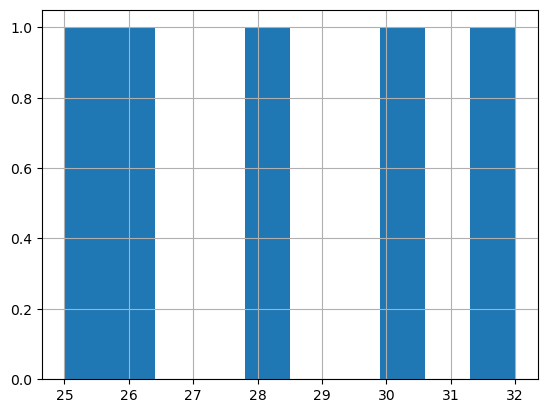

In [112]:
df = pd.read_csv("employees.csv")
df["Age"].hist()

<Axes: xlabel='Age', ylabel='Salary'>

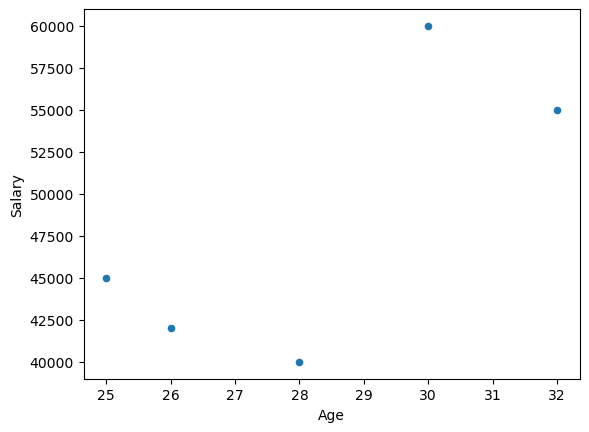

In [115]:
df = pd.read_csv("employees.csv")
df.plot(kind ="scatter",x ="Age", y ="Salary")

In [114]:
df

,ID,Name,Age,Department,Salary
0,E001,Amit Kumar,25,IT,45000
1,E002,Priya Singh,28,HR,40000
2,E003,Rahul Verma,32,Finance,55000
3,E004,Neha Sharma,26,Marketing,42000
4,E005,Arjun Patel,30,IT,60000


merging and joini data

In [135]:
import pandas as pd

# Customer DataFrame
df_customers = pd.DataFrame({
    "customer_id": [101, 102, 103, 104, 105],
    "name": [
        "amit kumar",
        "priya singh",
        "rahul verma",
        "neha sharma",
        "john smith"
    ]
})

# Orders DataFrame
df_orders = pd.DataFrame({
    "order_id": [1001, 1002, 1003, 1004, 1005, 1006],
    "customer_id": [101, 102, 103, 101, 104, 105],
    "amount": [2500, 1800, 3200, 1500, 4000, 2700]
})

print("Customers DataFrame")
print(df_customers)

print("\nOrders DataFrame")
print(df_orders)
# merge
pd.merge(df_customers, df_orders, on="customer_id") #inner join
 # left join
left_join = pd.merge(
    df_customers,
    df_orders,
    on="customer_id",
    how="left"
)

print(left_join)

# right join
right_join = pd.merge(
    df_customers,
    df_orders,
    on="customer_id",
    how="right"
)

print(right_join )


# oter join
outer_join = pd.merge(
    df_customers,
    df_orders,
    on="customer_id",
    how="outer"
)

print(outer_join)

Customers DataFrame
   customer_id         name
0          101   amit kumar
1          102  priya singh
2          103  rahul verma
3          104  neha sharma
4          105   john smith

Orders DataFrame
   order_id  customer_id  amount
0      1001          101    2500
1      1002          102    1800
2      1003          103    3200
3      1004          101    1500
4      1005          104    4000
5      1006          105    2700
   customer_id         name  order_id  amount
0          101   amit kumar      1001    2500
1          101   amit kumar      1004    1500
2          102  priya singh      1002    1800
3          103  rahul verma      1003    3200
4          104  neha sharma      1005    4000
5          105   john smith      1006    2700
   customer_id         name  order_id  amount
0          101   amit kumar      1001    2500
1          102  priya singh      1002    1800
2          103  rahul verma      1003    3200
3          101   amit kumar      1004    1500
4          